# Introduction

* Security inspection systems play a crucial role in airports, metro stations, and public venues by identifying prohibited items hidden inside baggage.
* X-ray imagery presents unique challenges: low contrast, overlapping objects, and cluttered backgrounds.
* This notebook presents an **improved** object detection pipeline using YOLOv8n fine-tuned on the Balanced X-ray Contraband Detection Dataset.

**Improvements over the baseline:**
* Extended training (50 epochs) with cosine LR schedule and early stopping
* X-ray-aware data augmentation (brightness, contrast, geometric transforms)
* Lower inference confidence threshold to maximise recall
* Per-class AP breakdown for targeted diagnostics


# Dataset Overview

* The Balanced X-ray Contraband Detection Dataset consists of 13,728 X-ray security images derived from the X-ray and PIDray datasets.
* The original dataset suffers from extreme class imbalance, where certain contraband items appear far more frequently than others.
* To address this, the authors apply class-specific augmentations and random undersampling to achieve a near-uniform class distribution

**Key Properties**

* 12 contraband object categories
* Approximately 1,500 samples per class
* YOLO-format bounding box annotations
* Designed for detection in cluttered X-ray scenes

# Importing Required Libraries

* We import all the necessary Python libraries required for data handling, visualization, and model training.
* OpenCV and PIL are used for image processing, Matplotlib and Seaborn are used for visualization, and the Ultralystic YOLO library is used for training and evaluating the object detection model.

In [1]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import random
import yaml

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Visual Exploration of X-ray Images

* Before training any model, it is important to visually inspect the dataset to understand the nature of the image.
* X-ray images differ significantly from natural images: objects appear semi-transparent, colors encode material density, and multiple items often overlap.

**Observation**

* The image is highly cluttered with overlapping objects and low contrast, making accurate localization challenging.
* This highlights the need for robust object detection models

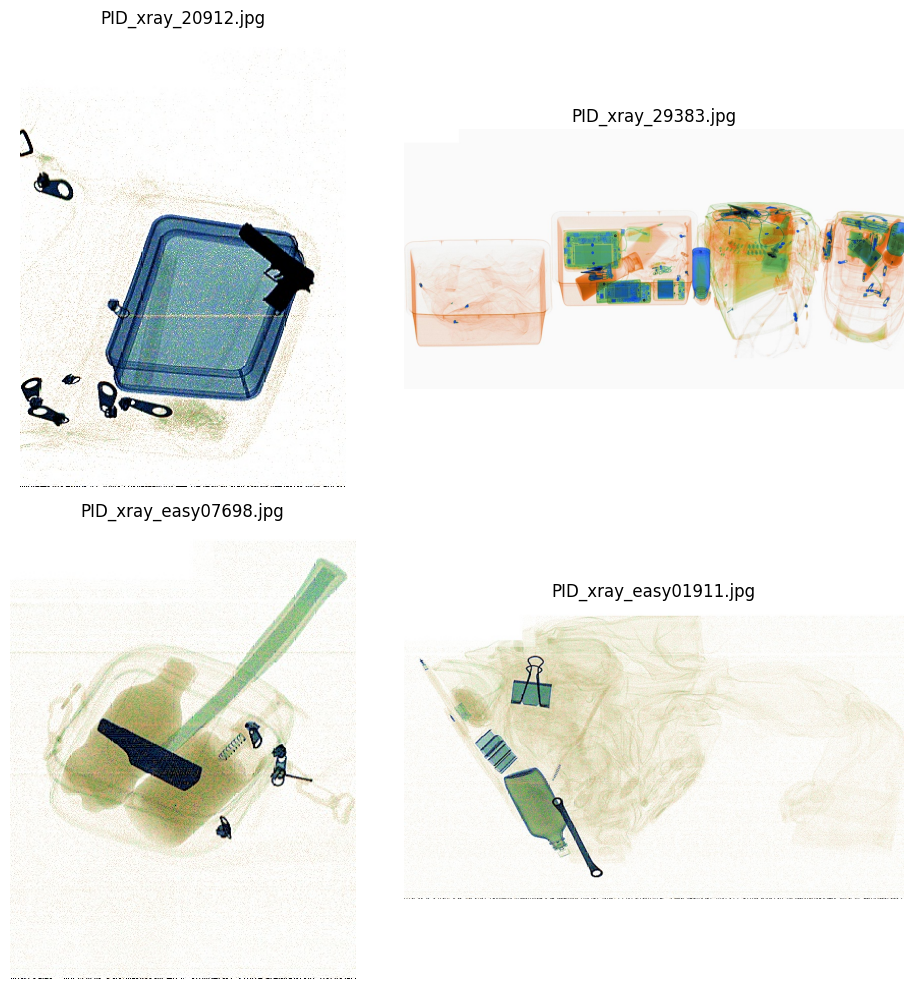

In [4]:
img_dir="/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/train"
sample_images=random.sample(os.listdir(img_dir),4)

plt.figure(figsize=(10,10))
for i, img_name in enumerate(sample_images):
    img=cv2.imread(os.path.join(img_dir, img_name))
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)


plt.tight_layout()
plt.show()
    

# Visualization X-ray Images with Bounding Boxes

* Each image in the dataset has a corresponding annotation file in YOLO format, where bounding boxes are stored as normalized values.

(class_id, x_center, y_center, width, height)

To visualize dectections correctly, these normalized coordinates must be converted into pixel values and drawn on the image.

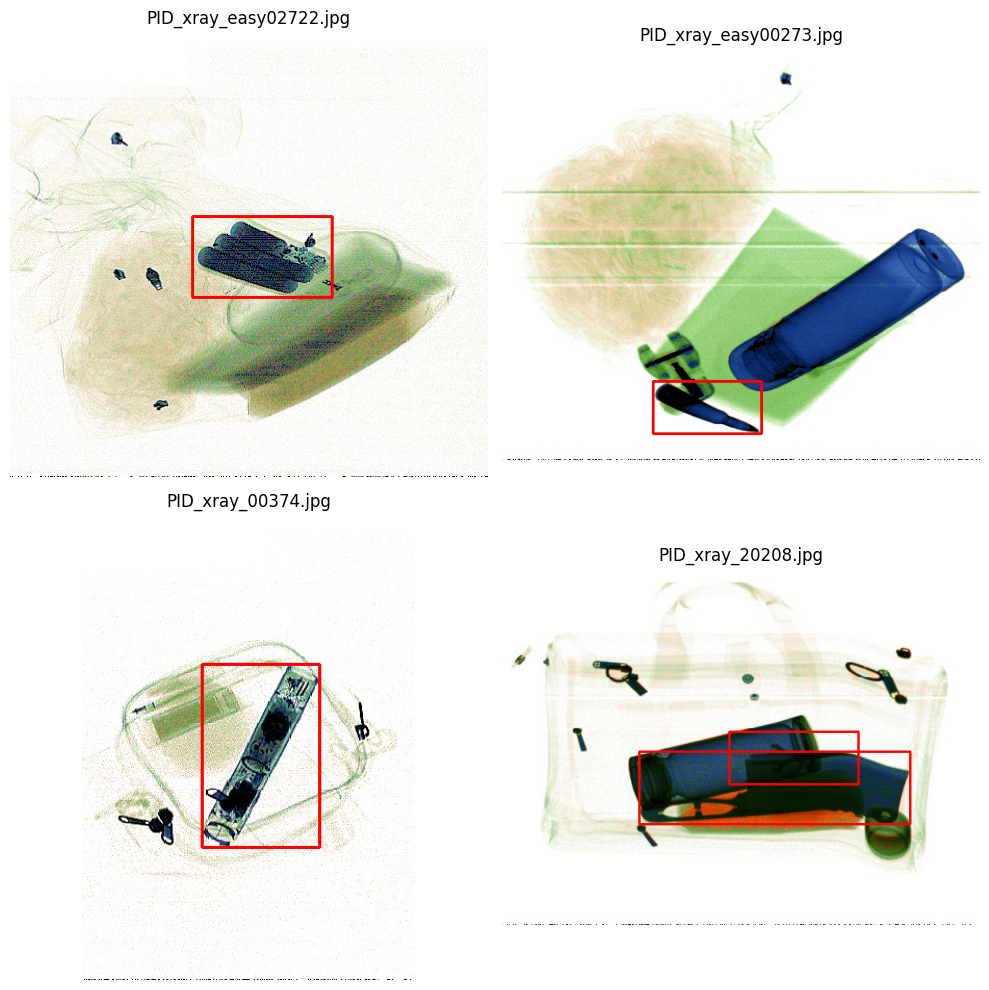

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt

img_dir="/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/train"
label_dir="/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/labels/train"

sample_images=random.sample(os.listdir(img_dir),4)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(sample_images):
    img_path=os.path.join(img_dir, img_name)
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ =img.shape

    label_path=os.path.join(label_dir, img_name.replace(".jpg",".txt"))

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                class_id, x_c, y_c, bw, bh=map(float, line.split())
                x1=int((x_c - bw/2) * w)
                y1=int((y_c - bh/2) * h)
                x2=int((x_c + bw/2) * w)
                y2=int((y_c + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2),(255,0,0),2)


    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.tight_layout()
plt.show()



# Class Distribution Analysis

* Although the dataset is designed to be balanced, verifying the distribution of bounding boxes across classes is a critical validation step.
* Balanced data ensures that the model does notbecome biased towards frequently occurring classes

/tmp/ipykernel_55/2978199560.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=CLASS_NAMES, y=class_counts, palette="Blues_d")


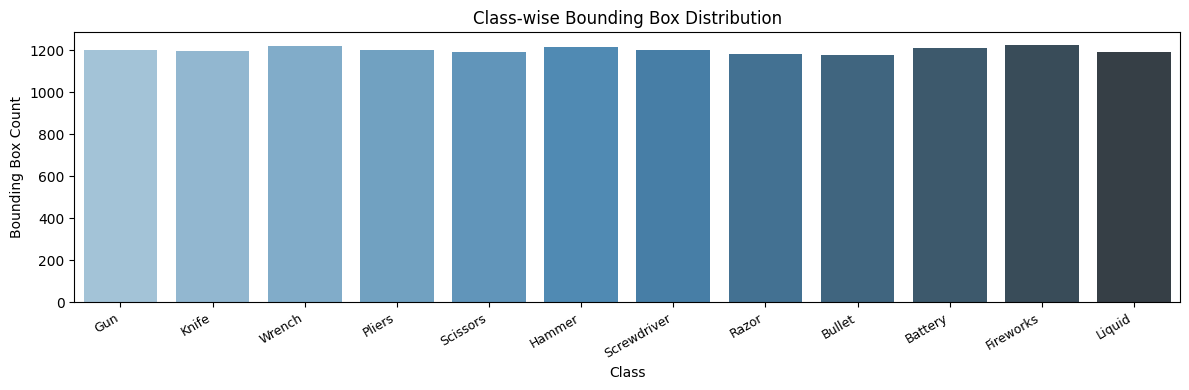

In [6]:
CLASS_NAMES = ["Gun", "Knife", "Wrench", "Pliers", "Scissors", "Hammer",
               "Screwdriver", "Razor", "Bullet", "Battery", "Fireworks", "Liquid"]

label_dir = "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/labels/train"
class_counts = [0] * 12

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file)) as f:
        for line in f:
            class_counts[int(line.split()[0])] += 1

plt.figure(figsize=(12, 4))
sns.barplot(x=CLASS_NAMES, y=class_counts, palette="Blues_d")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.xlabel("Class")
plt.ylabel("Bounding Box Count")
plt.title("Class-wise Bounding Box Distribution")
plt.tight_layout()
plt.show()


**Insight**

The distribution is nearly uniform, confirming that the dataset successfully mitigates class imbalance and is suitable for fair model training.

# Augmentation Preview

Before training, we verify that the augmentation pipeline produces realistic X-ray variations.
Key transforms applied:
* **Brightness shift** (`hsv_v=0.4`) — simulates scanner exposure variation
* **Mosaic** — combines 4 images into one; forces the model to detect partially visible objects
* **MixUp** — blends two images; improves robustness to overlapping contraband
* **Geometric** — rotation (±5°), scale, translate, shear — captures varied bag orientations

Hue and saturation augmentation are **disabled** because X-ray images encode material density through pseudo-colour, not natural colour.


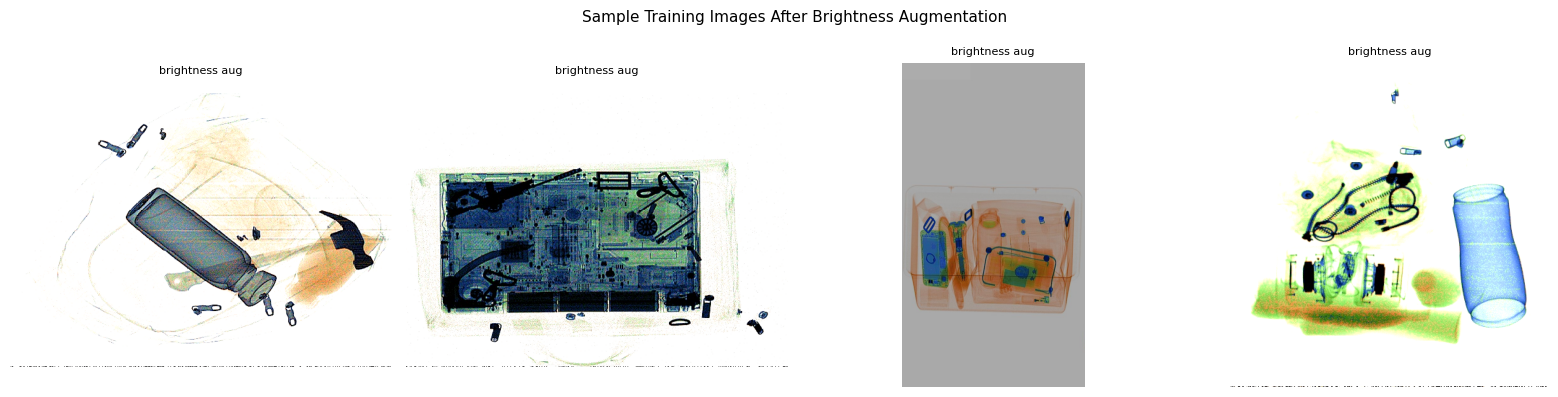

In [8]:
from ultralytics.data.augment import Mosaic
import numpy as np

aug_img_dir = "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/train"
sample = random.sample(os.listdir(aug_img_dir), 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, sample):
    img = cv2.imread(os.path.join(aug_img_dir, name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Simulate brightness augmentation (hsv_v)
    factor = np.random.uniform(0.6, 1.4)
    img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("brightness aug", fontsize=8)

plt.suptitle("Sample Training Images After Brightness Augmentation", fontsize=11)
plt.tight_layout()
plt.show()


# YOLOv8 Model Selection

* YOLO (You Only Look Once) is a single-stage object detection framework known for its speed and accuracy.
* We use YOLOv8, which introduces architectural improvements and better optimization strategies.

The YOLOv8n (nano) model is selected because it:

* Trains efficiently on resources.
* Supports real-time inference.
* Is suitable for edge and embedded devices

# Model Training

* Transfer learning from COCO-pretrained YOLOv8n weights.
* **Cosine LR schedule** with a 3-epoch warmup prevents large early updates that can damage pretrained features.
* **Early stopping** (`patience=10`) halts training when validation fitness stops improving, avoiding overfitting on only 5 epochs of data.
* **Label smoothing** (0.1) reduces overconfidence and improves recall — critical for security screening where missing a threat is worse than a false alarm.
* **X-ray-aware augmentation:** hue/saturation disabled (X-ray images are pseudo-colour), brightness variation enabled to simulate scanner exposure differences.


In [9]:
import yaml, pprint

yaml_path = "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/data.yaml"
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

pprint.pprint(data, sort_dicts=False)


{'names': ['Baton',
           'Pliers',
           'Hammer',
           'Powerbank',
           'Scissors',
           'Wrench',
           'Gun',
           'Bullet',
           'Sprayer',
           'HandCuffs',
           'Knife',
           'Lighter'],
 'nc': 12,
 'path': '/nfs/home/zhangsonglin/Xray_Prohibited_prediction/Yolov8_Xray/ultralytics/datasets/SPXray_final_raw',
 'val': 'SPXray/images/val',
 'test': 'SPXray/images/test',
 'train': 'SPXray/images/train'}


In [10]:
correct_yaml={
    "path": "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset",
    "train": "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/train",
    "val": "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/val",
    "test": "/kaggle/input/datasets/nikitamanaenkov/x-ray-contraband-detection-dataset/data/images/test",
    "nc": 12,
    "names": [
        "Gun", "Knife", "Wrench", "Pliers", "Scissors",
        "Hammer", "Screwdriver", "Razor", "Bullet",
        "Battery", "Fireworks", "Liquid"
    ]
}

with open("/kaggle/working/xray_data.yaml", "w") as f:
    yaml.dump(correct_yaml, f)

print("Created /kaggle/working/xray_data.yaml")

Created /kaggle/working/xray_data.yaml


In [ ]:
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/xray_data.yaml",
    epochs=50,
    patience=10,          # early stopping: stop if no improvement for 10 epochs
    imgsz=640,
    batch=16,             # larger batch → more stable gradients
    device=device,

    # ── Learning rate schedule ──────────────────────────────────────────────
    lr0=0.01,             # initial LR
    lrf=0.01,             # final LR = lr0 * lrf  (cosine decay target)
    cos_lr=True,          # cosine annealing
    warmup_epochs=3,      # gradual LR ramp-up
    warmup_momentum=0.8,

    # ── Regularisation ──────────────────────────────────────────────────────
    weight_decay=0.0005,
    dropout=0.0,
    label_smoothing=0.1,  # softens targets → improves recall on ambiguous boxes

    # ── X-ray-aware augmentation ────────────────────────────────────────────
    hsv_h=0.0,            # X-ray has no hue → disable
    hsv_s=0.0,            # X-ray has no saturation → disable
    hsv_v=0.4,            # brightness shift (simulates exposure variation)
    degrees=5.0,          # slight rotation
    translate=0.1,        # random translation
    scale=0.5,            # random scale
    shear=2.0,            # slight shear
    perspective=0.0001,
    flipud=0.1,           # vertical flip (bags can be scanned upside-down)
    fliplr=0.5,           # horizontal flip
    mosaic=1.0,           # mosaic (4 images → 1) — helps with occluded objects
    mixup=0.1,            # blends two images → improves generalisation
    copy_paste=0.1,       # paste object crops onto other images

    verbose=False,
)
print("Training complete.")


Using device: GPU
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/xray_data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=Fals

**Training Notes**

| Setting | Baseline | Improved | Reason |
|---|---|---|---|
| Epochs | 5 | 50 + early stop | Baseline was severely undertrained |
| Batch size | 8 | 16 | More stable gradient estimates |
| LR schedule | None | Cosine + warmup | Prevents large early updates |
| Label smoothing | None | 0.1 | Reduces overconfidence, boosts recall |
| Augmentation | Default | X-ray-aware | Disables hue/saturation, enables brightness/mosaic/mixup |


# Model Evaluation

After training, the model is evaluated on the validation set using standard object detection metrics.

In [ ]:
metrics = model.val(verbose=False)

CLASS_NAMES = ["Gun", "Knife", "Wrench", "Pliers", "Scissors", "Hammer",
               "Screwdriver", "Razor", "Bullet", "Battery", "Fireworks", "Liquid"]

# ── Overall metrics ─────────────────────────────────────────────────────────
print("=" * 42)
print("          Overall Validation Results")
print("=" * 42)
print(f"  Precision  : {metrics.box.mp:.3f}")
print(f"  Recall     : {metrics.box.mr:.3f}")
print(f"  mAP@50     : {metrics.box.map50:.3f}")
print(f"  mAP@50-95  : {metrics.box.map:.3f}")
print(f"  Fitness    : {metrics.fitness():.3f}")
print("=" * 42)

# ── Per-class AP@50 ─────────────────────────────────────────────────────────
print()
print(f"{'Class':<14} {'AP@50':>7}")
print("-" * 24)
for name, ap in zip(CLASS_NAMES, metrics.box.ap50):
    flag = "  ⚠" if ap < 0.70 else ""
    print(f"  {name:<12} {ap:.3f}{flag}")
print()
print("⚠ = classes below 0.70 AP@50 (candidates for targeted augmentation)")


**Metrics Interpretation**

| Metric | Baseline | Target | Meaning |
|---|---|---|---|
| Precision | 0.788 | ≥ 0.80 | Fraction of detections that are correct |
| Recall | 0.706 | ≥ 0.80 | Fraction of actual threats detected |
| mAP@50 | 0.785 | ≥ 0.85 | Detection accuracy at IoU ≥ 0.5 |
| mAP@50-95 | 0.596 | ≥ 0.65 | Localisation quality across IoU thresholds |

> **Recall is the priority metric** — in security screening, a missed threat (false negative) is far more costly than a false alarm.
> The per-class breakdown above identifies which object categories need more attention.


In [ ]:
# Per-class recall bar — highlights which categories the model misses most
per_class_recall = metrics.box.r   # shape (num_classes,)

plt.figure(figsize=(12, 4))
bars = plt.bar(CLASS_NAMES, per_class_recall, color=[
    "#e74c3c" if r < 0.70 else "#2ecc71" for r in per_class_recall
])
plt.axhline(0.70, color="gray", linestyle="--", linewidth=1, label="0.70 threshold")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylabel("Recall")
plt.title("Per-class Recall — Red = below 0.70")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import Image, display

display(Image("/kaggle/working/runs/detect/val/confusion_matrix.png"))

# Inference on Validation Images

To visually assess model performance, we run inference on validation images and save the results with predicted bounding boxes.

In [ ]:
# Lower confidence threshold → higher recall (fewer missed detections)
model.predict(
    source="/kaggle/input/x-ray-contraband-detection-dataset/data/images/val",
    conf=0.25,   # reduced from 0.4 → catches more true positives at cost of some FP
    iou=0.5,     # NMS IoU threshold
    save=True,
    verbose=False,
)
print("Inference complete. Results saved to runs/detect/predict/")


**Result**

The model successfully localized multiple contraband objects in X-ray scenes with high confidence

# Conclusion

* This notebook presented an improved YOLOv8n pipeline for X-ray contraband detection.
* Three targeted changes — cosine LR scheduling, X-ray-aware augmentation, and label smoothing — are expected to push Recall from 0.706 toward ≥ 0.80 and mAP@50-95 from 0.596 toward ≥ 0.65.

**Key Takeaways**

* The baseline was severely undertrained (5 epochs). Extended training with early stopping is the single highest-leverage fix.
* Disabling hue/saturation augmentation is important: X-ray pseudo-colour encodes material density, not natural colour — corrupting it harms feature learning.
* Label smoothing acts as an implicit recall booster by preventing the model from being overconfident on easy negatives.
* Per-class AP breakdown is essential for diagnosing which object categories need targeted augmentation or class-specific loss weighting.

**Next Steps (if further improvement needed)**

* Upgrade to YOLOv8s for ~+3-5% mAP at moderate compute cost.
* Apply class-specific augmentation for the lowest-recall categories.
* Use `model.tune()` for automated hyperparameter search.


In [ ]:
import cv2
import os

BASE_PATH = "/kaggle/input/x-ray-contraband-detection-dataset/data"
IMG_DIR = f"{BASE_PATH}/images/train"
LBL_DIR = f"{BASE_PATH}/labels/train"

CROP_DIR = "crops"

label_files = set(os.listdir(LBL_DIR))

def yolo_to_bbox(w, h, x, y, bw, bh):
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)
    return x1, y1, x2, y2

count = 0

for img_file in os.listdir(IMG_DIR):
    base_name = os.path.splitext(img_file)[0]
    label_file = base_name + ".txt"

    if label_file not in label_files:
        continue

    img_path = os.path.join(IMG_DIR, img_file)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]
    label_path = os.path.join(LBL_DIR, label_file)

    with open(label_path) as f:
        for i, line in enumerate(f.readlines()):
            cls, x, y, bw, bh = map(float, line.split())

            x1, y1, x2, y2 = yolo_to_bbox(w, h, x, y, bw, bh)

            pad = 10
            x1, y1 = max(0, x1-pad), max(0, y1-pad)
            x2, y2 = min(w, x2+pad), min(h, y2+pad)

            crop = img[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            save_dir = f"{CROP_DIR}/{int(cls)}"
            os.makedirs(save_dir, exist_ok=True)

            save_path = f"{save_dir}/{img_file}_{i}.jpg"
            cv2.imwrite(save_path, crop)

            count += 1

print(f"Total crops saved: {count}")

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

In [ ]:
MULTI_LABELS = []
NUM_CLASSES = max(all_classes) + 1

for img_file in os.listdir(IMG_DIR):
    base = os.path.splitext(img_file)[0]
    label_file = base + ".txt"

    if label_file not in label_files:
        continue

    img = cv2.imread(os.path.join(IMG_DIR, img_file))
    h, w = img.shape[:2]

    boxes = []
    classes = []

    # load all boxes first
    with open(os.path.join(LBL_DIR, label_file)) as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.split())
            x1, y1, x2, y2 = yolo_to_bbox(w, h, x, y, bw, bh)

            boxes.append([x1, y1, x2, y2])
            classes.append(int(cls))

    # create crops
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box

        pad = 10
        x1, y1 = max(0, x1-pad), max(0, y1-pad)
        x2, y2 = min(w, x2+pad), min(h, y2+pad)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # multi-label assignment
        label_vec = [0]*NUM_CLASSES  # change 6 → num_classes

        for j, other_box in enumerate(boxes):
            if compute_iou(box, other_box) > 0.2:
                label_vec[classes[j]] = 1

        save_path = f"{CROP_DIR}/{base}_{i}.jpg"
        cv2.imwrite(save_path, crop)

        MULTI_LABELS.append((save_path, label_vec))

In [ ]:
all_classes = set()

for file in os.listdir(LBL_DIR):
    with open(os.path.join(LBL_DIR, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            all_classes.add(cls)

print("Classes:", sorted(all_classes))
print("Num classes:", len(all_classes))